# Task 3 — Cognitive load and the data-ink ratio

**CLO1.** Working memory holds about **4 ± 1** chunks. Three kinds of load (Sweller):
**intrinsic** (in the data — cannot be removed, only sequenced), **extraneous** (added
by the design — chart junk, legends, decode work — **remove it, that is the job**), and
**germane** (the effort of actually understanding — protect it). Tufte's **data-ink
ratio** = ink that encodes data ÷ total ink; maximise it, but not past the point where
the chart gets harder to read.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
cc = pd.read_csv("data/car_crashes.csv")
print(cc.shape)
cc.head()

(51, 8)


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


## 1. An overloaded chart, on purpose — `BAD EXAMPLE`

All 51 rows as bars of `total`, with every kind of extraneous load piled on: a
different colour per bar, all 51 labels rotated, heavy gridlines in **both** directions,
a full box frame, a 51-entry legend, and a title that names the axes instead of stating
a finding. It is labelled `BAD EXAMPLE` so it is read as a demonstration, not a mistake.

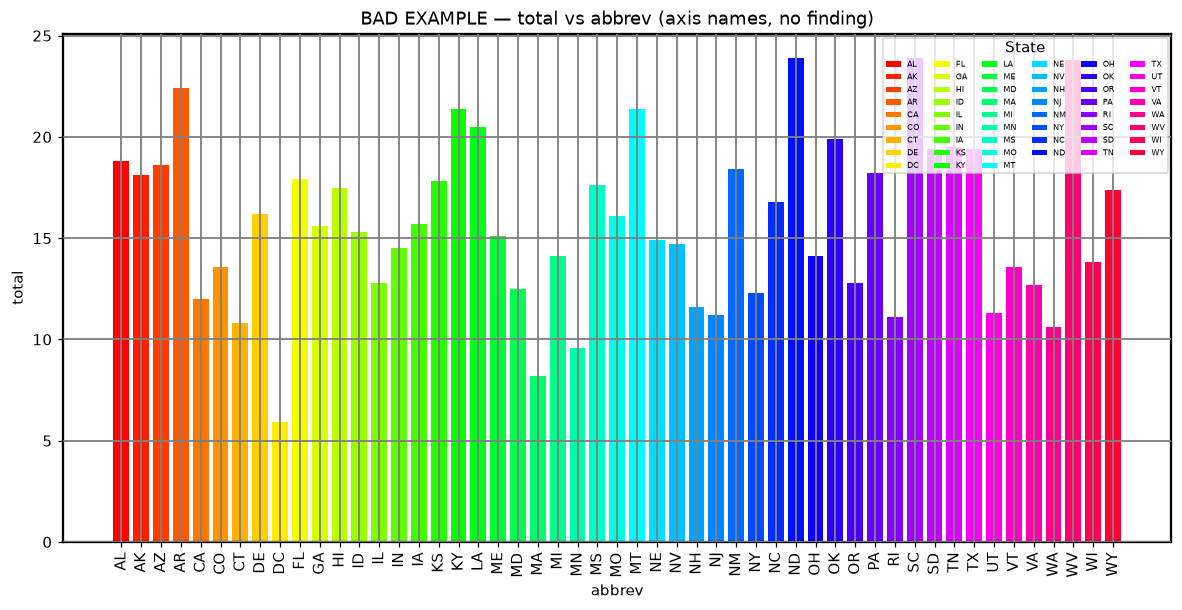

In [2]:
cmap = plt.get_cmap("hsv")
colors = [cmap(i / len(cc)) for i in range(len(cc))]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(cc["abbrev"], cc["total"], color=colors,
              label=list(cc["abbrev"]))   # feeds a 51-entry legend
ax.grid(True, which="both", axis="both", color="grey", linewidth=1.2)
ax.set_axisbelow(False)
ax.set_xticks(range(len(cc)))
ax.set_xticklabels(cc["abbrev"], rotation=90)
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(True); ax.spines[side].set_linewidth(1.5)
ax.legend(ncol=6, fontsize=5, loc="upper right", title="State")
ax.set_title("BAD EXAMPLE — total vs abbrev (axis names, no finding)")
ax.set_xlabel("abbrev"); ax.set_ylabel("total")
fig.savefig("bad_example_task3.png", bbox_inches="tight")
plt.show()

## 2. Count the load, and estimate the data-ink ratio

| Element | Load type | Why |
|---|---|---|
| The 51 bar heights | **germane/data** | the only marks encoding a number |
| 51 different bar colours | **extraneous** | colour carries no variable — pure decoration |
| 51-entry legend | **extraneous** | duplicates the x tick labels; forces a decode |
| Heavy gridlines both axes | **extraneous** | far more ink than any comparison needs |
| Full 4-sided box frame | **extraneous** | two spines already locate the data |
| Rotated 51 x labels | partly intrinsic | identity labels are needed, but 51 at once overflow 4±1 |
| Axis-naming title | **extraneous** | states no finding, so does no germane work |
| Intrinsic load | **intrinsic** | 51 states is genuinely 51 things — cannot be deleted, only chunked |

**Data-ink ratio (working shown).** Count marks, roughly:
- Ink that encodes data: 51 bar rectangles = **51**.
- Total ink: 51 bars + 51 legend swatches + ~12 gridlines + 4 frame spines + legend box
  ≈ 51 + 51 + 12 + 4 + 1 = **119**.

$$\text{data-ink ratio} \approx \frac{51}{119} \approx 0.43$$

So well under half the ink is doing any work. Most of the rest is extraneous and can go.

In [3]:
# show the arithmetic as code too
data_ink = len(cc)
total_ink = len(cc) + len(cc) + 12 + 4 + 1
print(f"data ink  = {data_ink}")
print(f"total ink ~ {total_ink}")
print(f"data-ink ratio ~ {data_ink/total_ink:.2f}")

data ink  = 51
total ink ~ 119
data-ink ratio ~ 0.43


## 3. Strip it down, one step at a time

Five panels, the same data getting lighter at each step. Order and justification:
**(1)** drop the legend (it duplicated the x labels) → **(2)** drop the box frame and
the y-gridline clutter → **(3)** collapse to a single hue → **(4)** **sort the bars**
(adds no ink, yet is the single highest-value edit — it turns "look up each state" into
"read a ranking") → **(5)** keep colour for one highlighted bar and grey the rest, label
only what matters.

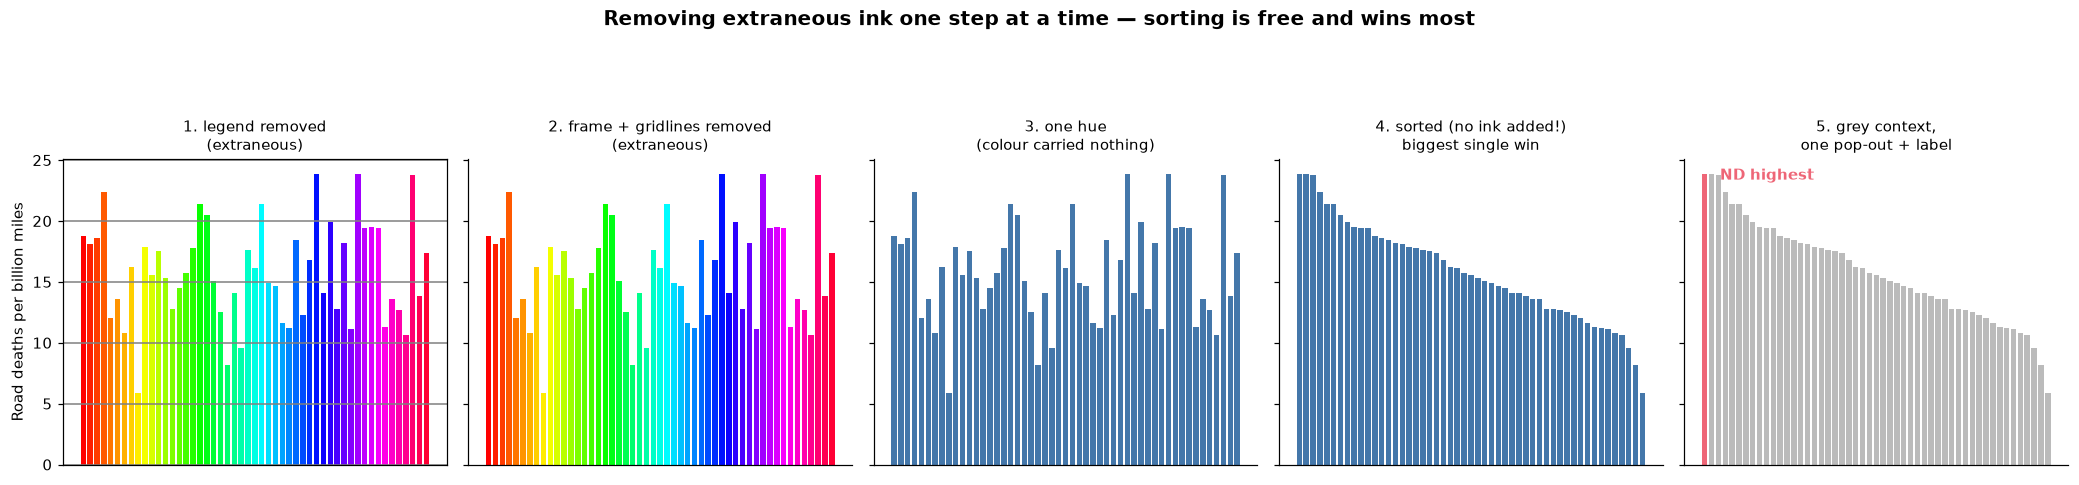

In [4]:
ccs = cc.sort_values("total", ascending=False).reset_index(drop=True)
top_idx = 0  # the max state, to highlight in the last panel

fig, axes = plt.subplots(1, 5, figsize=(19, 4.2), sharey=True)

# panel 1: just remove the legend
axes[0].bar(cc["abbrev"], cc["total"], color=colors)
axes[0].grid(True, axis="both", color="grey", lw=1.0)
for s in ("top", "right", "left", "bottom"):
    axes[0].spines[s].set_visible(True)
axes[0].set_title("1. legend removed\n(extraneous)", fontsize=10)

# panel 2: remove frame + gridlines
axes[1].bar(cc["abbrev"], cc["total"], color=colors)
for s in ("top", "right"):
    axes[1].spines[s].set_visible(False)
axes[1].set_title("2. frame + gridlines removed\n(extraneous)", fontsize=10)

# panel 3: single hue
axes[2].bar(cc["abbrev"], cc["total"], color="#4477aa")
for s in ("top", "right"):
    axes[2].spines[s].set_visible(False)
axes[2].set_title("3. one hue\n(colour carried nothing)", fontsize=10)

# panel 4: sort
axes[3].bar(ccs["abbrev"], ccs["total"], color="#4477aa")
for s in ("top", "right"):
    axes[3].spines[s].set_visible(False)
axes[3].set_title("4. sorted (no ink added!)\nbiggest single win", fontsize=10)

# panel 5: grey context, one coloured + labelled
bar_colors = ["#bbbbbb"] * len(ccs)
bar_colors[top_idx] = "#ee6677"
axes[4].bar(ccs["abbrev"], ccs["total"], color=bar_colors)
axes[4].annotate(f"{ccs['abbrev'][top_idx]} highest",
                 (top_idx, ccs["total"][top_idx]), xytext=(10, -4),
                 textcoords="offset points", color="#ee6677", fontweight="bold")
for s in ("top", "right"):
    axes[4].spines[s].set_visible(False)
axes[4].set_title("5. grey context,\none pop-out + label", fontsize=10)

for ax in axes:
    ax.set_xticks([]); ax.set_ylim(0, None)
axes[0].set_ylabel("Road deaths per billion miles")
fig.suptitle("Removing extraneous ink one step at a time — sorting is free and wins most",
             fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("declutter_steps.png", bbox_inches="tight")
plt.show()

**Load removed at each step.** 1: the legend was pure **extraneous** duplication. 2:
gridlines and frame were **extraneous** — two spines suffice. 3: per-bar colour encoded
nothing, so it was **extraneous**; one hue restores the data-ink. 4: **sorting adds no
ink** yet converts a lookup into a ranking — it protects **germane** effort by removing
search. 5: grey-for-context + one coloured bar aims all remaining colour ink at the
title's message.

## 4. Respect the 4 ± 1 limit

51 states is far past 4 ± 1. I chunk the 50 states + DC into the **four US Census
regions** and show the region means — four bars, four chunks. **What it costs:** every
chunking hides something; this one hides **all within-region variation** (a high-crash
state and a low-crash state in the same region are averaged into one bar). I name that
cost rather than pretend the chart is lossless.

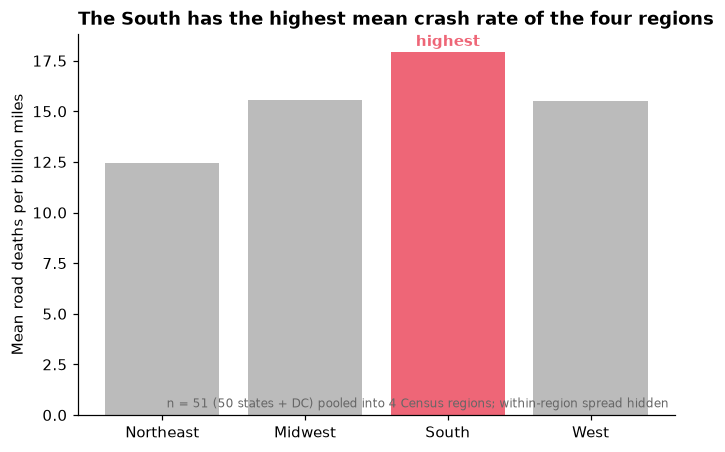

In [5]:
REGION = {
 "CT":"NE","ME":"NE","MA":"NE","NH":"NE","RI":"NE","VT":"NE","NJ":"NE","NY":"NE","PA":"NE",
 "IL":"MW","IN":"MW","MI":"MW","OH":"MW","WI":"MW","IA":"MW","KS":"MW","MN":"MW","MO":"MW",
 "NE":"MW","ND":"MW","SD":"MW",
 "DE":"S","FL":"S","GA":"S","MD":"S","NC":"S","SC":"S","VA":"S","WV":"S","DC":"S","AL":"S",
 "KY":"S","MS":"S","TN":"S","AR":"S","LA":"S","OK":"S","TX":"S",
 "AZ":"W","CO":"W","ID":"W","MT":"W","NV":"W","NM":"W","UT":"W","WY":"W","AK":"W","CA":"W",
 "HI":"W","OR":"W","WA":"W",
}
cc["region"] = cc["abbrev"].map(REGION)
assert cc["region"].notna().all(), cc[cc["region"].isna()]["abbrev"].tolist()
reg = cc.groupby("region")["total"].mean().reindex(["NE", "MW", "S", "W"])
names = {"NE": "Northeast", "MW": "Midwest", "S": "South", "W": "West"}

fig, ax = plt.subplots(figsize=(7, 4.5))
cols = ["#bbbbbb"] * 4
cols[int(np.argmax(reg.values))] = "#ee6677"   # one pop-out: worst region
ax.bar([names[r] for r in reg.index], reg.values, color=cols)
ax.annotate("highest", (int(np.argmax(reg.values)), reg.max()),
            xytext=(0, 4), textcoords="offset points", ha="center",
            color="#ee6677", fontweight="bold")
ax.set_title("The South has the highest mean crash rate of the four regions",
             loc="left", fontweight="bold")
ax.set_ylabel("Mean road deaths per billion miles")
ax.set_ylim(0, None)
ax.text(0.99, 0.02, "n = 51 (50 states + DC) pooled into 4 Census regions; "
        "within-region spread hidden", transform=ax.transAxes, ha="right", fontsize=8,
        color="#666666")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

**Chunking chosen:** four Census regions (four chunks, inside 4 ± 1). **Cost named:** the
spread within each region is gone — you can no longer see that one southern state is an
outlier. A small-multiple of four region panels would keep the detail at the price of
more chunks; I chose the four-bar version because the task is "which region is worst",
and four bars answers it without overflowing working memory.

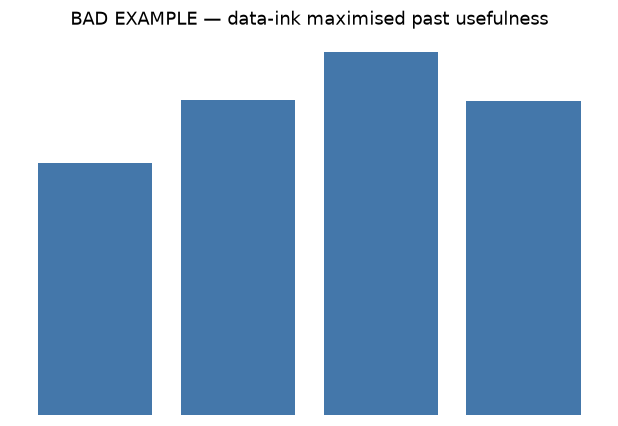

In [6]:
## 5. Over-strip it — BAD EXAMPLE
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(range(4), reg.values, color="#4477aa")
ax.set_xticks([]); ax.set_yticks([])
for s in ("top", "right", "left", "bottom"):
    ax.spines[s].set_visible(False)
ax.set_title("BAD EXAMPLE — data-ink maximised past usefulness")
fig.savefig("over_stripped.png", bbox_inches="tight")
plt.show()

**Why this fails.** The data-ink ratio is now near 1 — almost every mark is a bar — yet
the chart is **useless**: no axis, no tick values, no units, no region names. You can
see four bars differ but cannot say *what* they measure or *by how much*. Removing the
y-axis scale and the category labels deleted **germane** information, not extraneous
ink.

**Stopping rule (one sentence):** *remove ink until the next thing you would remove is
something the reader needs to answer the chart's question — then stop.*

## 6. The question — where ADDING ink lowers load (`tips.csv`)

A scatter of tip vs total bill. Adding a **15 %-tip reference line** and a short
annotation is **more** ink, but it **lowers** cognitive load: without it the reader must
mentally compute 15 % of each bill and compare — a calculation per point. The line does
that calculation once, so judging "above or below a standard tip" becomes a single
preattentive position comparison.

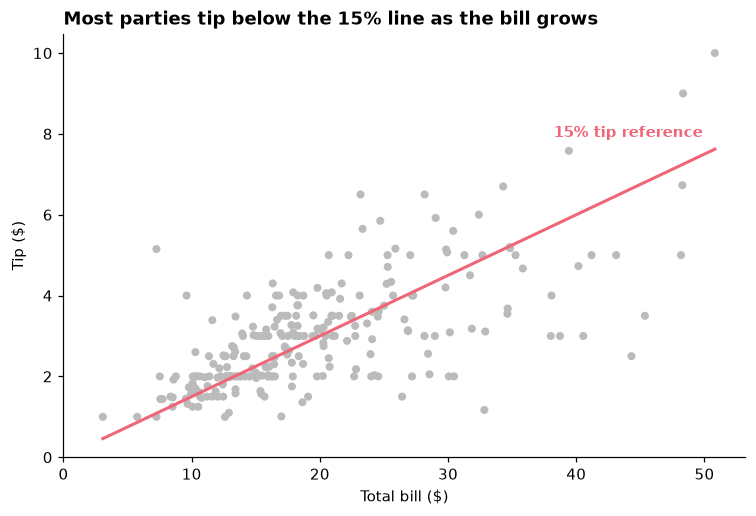

In [7]:
tips = pd.read_csv("data/tips.csv")
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(tips["total_bill"], tips["tip"], color="#bbbbbb", s=28, edgecolors="none")
xs = np.linspace(tips["total_bill"].min(), tips["total_bill"].max(), 2)
ax.plot(xs, 0.15 * xs, color="#ee6677", lw=2)   # the added ink
ax.annotate("15% tip reference", (xs[1], 0.15 * xs[1]), xytext=(-8, 8),
            textcoords="offset points", ha="right", color="#ee6677", fontweight="bold")
ax.set_title("Most parties tip below the 15% line as the bill grows",
             loc="left", fontweight="bold")
ax.set_xlabel("Total bill ($)"); ax.set_ylabel("Tip ($)")
ax.set_xlim(0, None); ax.set_ylim(0, None)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.savefig("tips_reference_line.png", bbox_inches="tight")
plt.show()

**Why "maximise data-ink" is a heuristic, not a rule.** The reference line is
non-data ink by Tufte's strict count, yet it removes a per-point mental calculation and
replaces it with one position judgement — so it **lowers** load while **lowering** the
data-ink ratio. The principle is a default that usually points the right way (kill
decoration), but it is serving the real goal — minimum total effort for the reader — and
sometimes that goal is met by *adding* a well-chosen mark. Follow the reader, not the
ratio.